In [ ]:
!pip -q install transformers accelerate lpips torchmetrics[image] scikit-image scipy pandas pyarrow kornia requests

# Mount Drive only to persist checkpoints/results — data lives in session storage
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_AVAILABLE = True
    print("Drive mounted — results will be saved to Drive.")
except Exception:
    DRIVE_AVAILABLE = False
    print("Drive not mounted — results will be saved to /content/ only.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted — results will be saved to Drive.


In [ ]:
import os, glob, zipfile

# ── DATASET CONFIG ─────────────────────────────────────────────
N_IMAGES   = -1
KAGGLE_DS  = "abdelrahmanelgharibx/coco2017-subset"
LOCAL_DIR  = "/content/coco_local"            # all images end up here
# ───────────────────────────────────────────────────────────────

if os.path.isdir(LOCAL_DIR) and len(os.listdir(LOCAL_DIR)) > 0:
    print("Dataset already present, skipping download.")
else:
    # kagglehub is pre-installed on Colab; downloads + caches the dataset
    import kagglehub
    dl_path = kagglehub.dataset_download(KAGGLE_DS)
    print(f"Downloaded to: {dl_path}")

    # Unpack: find all images regardless of subfolder structure
    os.makedirs(LOCAL_DIR, exist_ok=True)
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

    # If download contains zip files, extract them first
    for zf in glob.glob(os.path.join(dl_path, "**", "*.zip"), recursive=True):
        print(f"Extracting {zf}…")
        with zipfile.ZipFile(zf) as z:
            z.extractall(dl_path)

    # Flatten all images into LOCAL_DIR
    count = 0
    for root, _, files in os.walk(dl_path):
        for fn in files:
            if os.path.splitext(fn)[1].lower() in IMG_EXTS:
                src = os.path.join(root, fn)
                dst = os.path.join(LOCAL_DIR, fn)
                if not os.path.exists(dst):
                    os.link(src, dst) if os.stat(src).st_dev == os.stat(LOCAL_DIR).st_dev else __import__('shutil').copy2(src, dst)
                    count += 1
    print(f"Moved {count} images into {LOCAL_DIR}")

# Final check
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
all_files = sorted([
    f for f in os.listdir(LOCAL_DIR)
    if os.path.splitext(f)[1].lower() in IMG_EXTS
])
print(f"Total images: {len(all_files)}")
if N_IMAGES > len(all_files):
    print(f"⚠ Requested {N_IMAGES} but only {len(all_files)} available — using all.")
    N_IMAGES = len(all_files)

selected_files = all_files[-N_IMAGES:]
IMAGES_DIR = LOCAL_DIR
print(f"✅ Dataset ready — {len(selected_files)} images in {IMAGES_DIR}")


100%|██████████| 11.7G/11.7G [00:53<00:00, 235MB/s]


Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/abdelrahmanelgharibx/coco2017-subset/versions/1
Moved 76079 images into /content/coco_local
Total images: 76079
✅ Dataset ready — 76078 images in /content/coco_local


In [ ]:
import os,random,math,warnings,json,glob,copy,csv,time,re
import numpy as np,pandas as pd,matplotlib.pyplot as plt
import torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms; from PIL import Image
from tqdm.auto import tqdm; from skimage import color as skcolor
from skimage.color import deltaE_ciede2000
import lpips
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image import PeakSignalNoiseRatio,StructuralSimilarityIndexMeasure
from transformers import BlipProcessor,BlipForConditionalGeneration
from transformers import CLIPTokenizer,CLIPTextModel

def seed_all(s=42):
    random.seed(s);np.random.seed(s);torch.manual_seed(s);torch.cuda.manual_seed_all(s)

# ── Paths wired from the dataset download cell ──
_SAVE_BASE = ("/content/drive/My Drive/colorization_runs_coco2017"
              if DRIVE_AVAILABLE else "/content/colorization_runs")
_CACHE_BASE = ("/content/drive/My Drive/colorization_cache_coco2017"
               if DRIVE_AVAILABLE else "/content/colorization_cache")

CONFIG={
 # Dataset — N_IMAGES and IMAGES_DIR are set by the download cell above
 "n_images":N_IMAGES,        # mirrors the download cell for logging
 "images_dir":IMAGES_DIR,    # session-local copy from Drive
 "train_ratio":0.70,"val_ratio":0.15,"test_ratio":0.15,"seed":42,
 "img_size":256,"batch_size":16,"epochs":25,
 "lr_g":2e-4,"lr_d":2e-4,"lr_g_reg":2e-4,"lr_g_mdn":1e-4,
 "lambda_adv":1.0,"lambda_lpips":1.0,"lambda_recon":2.0,
 "gan_warmup_epochs_reg":3,"gan_warmup_epochs_mdn":2,
 "lambda_adv_reg":0.1,"lambda_adv_mdn":0.1,
 "lambda_recon_reg":10.0,"lambda_recon_mdn":5.0,
 "mdn_K":5,"mdn_min_sigma":1e-3,"mdn_log_sigma_min":-7.0,"mdn_log_sigma_max":3.0,
 "use_text":True,"text_dim":512,"max_text_tokens":20,
 "caption_max_new_tokens":20,
 "caption_model":"Salesforce/blip-image-captioning-base",
 "clip_text_model":"openai/clip-vit-base-patch32",
 "text_mode":"token_attn",
 "lambda_chroma":0.1,
 "cache_text":False,
 "cache_dir":_CACHE_BASE,
 "save_dir":_SAVE_BASE,
 "early_stopping":True,"es_patience":5,"es_min_delta":1e-4,
 "device":"cuda" if torch.cuda.is_available() else "cpu",
 "num_workers":0,"clip_grad":1.0,"eval_max_batches":50,
 "mdn_temperatures":[0.5,0.8,1.0,1.5],"mdn_best_of_n":5,
}
os.makedirs(CONFIG["cache_dir"],exist_ok=True)
os.makedirs(CONFIG["save_dir"],exist_ok=True)
seed_all(CONFIG["seed"])
print(f"Device: {CONFIG['device']} | N_IMAGES: {CONFIG['n_images']} | cache_text: {CONFIG['cache_text']}")
print(f"Images : {CONFIG['images_dir']}")
print(f"Runs   : {CONFIG['save_dir']}")


Device: cuda | N_IMAGES: -1 | cache_text: False
Images : /content/coco_local
Runs   : /content/drive/My Drive/colorization_runs_coco2017


In [ ]:
images_dir=CONFIG['images_dir']
IMG_EXTS={'.jpg','.jpeg','.png','.bmp','.tiff','.webp'}
image_paths=sorted([
    os.path.join(images_dir,f) for f in os.listdir(images_dir)
    if os.path.splitext(f)[1].lower() in IMG_EXTS
])
assert len(image_paths)>0
# Limit to N_IMAGES (take last N for deterministic subset)
if CONFIG["n_images"]>0 and CONFIG["n_images"]<len(image_paths):
    image_paths=image_paths[-CONFIG["n_images"]:]
    print(f"Using last {len(image_paths)} of available images")
cache_tag = "all" if CONFIG["n_images"] == -1 else str(CONFIG["n_images"])
split_file=os.path.join(CONFIG["cache_dir"],f"split_indices_n{cache_tag}.json")
use_cached=False
if os.path.exists(split_file):
    try:
        with open(split_file) as f: sd=json.load(f)
        train_idx,val_idx,test_idx=sd["train"],sd["val"],sd["test"]
        all_idx=train_idx+val_idx+test_idx
        if all_idx and max(all_idx)<len(image_paths):
            use_cached=True
            print(f"Loaded cached split: {split_file}")
        else:
            print(f"Cached split invalid for current files. Regenerating: {split_file}")
    except Exception:
        print(f"Could not read split cache. Regenerating: {split_file}")
if not use_cached:
    seed_all(CONFIG["seed"])
    idx=list(range(len(image_paths)));random.shuffle(idx)
    n=len(idx);nt=int(n*CONFIG["train_ratio"]);nv=int(n*CONFIG["val_ratio"])
    train_idx,val_idx,test_idx=sorted(idx[:nt]),sorted(idx[nt:nt+nv]),sorted(idx[nt+nv:])
    with open(split_file,"w") as f:
        json.dump({"seed":CONFIG["seed"],"n_images":CONFIG["n_images"],"train":train_idx,"val":val_idx,"test":test_idx},f)
    print(f"Saved split cache: {split_file}")
train_paths=[image_paths[i] for i in train_idx]
val_paths=[image_paths[i] for i in val_idx]
test_paths=[image_paths[i] for i in test_idx]
print(f"Train:{len(train_paths)} Val:{len(val_paths)} Test:{len(test_paths)}")


Saved split cache: /content/drive/My Drive/colorization_cache_coco2017/split_indices_nall.json
Train:53255 Val:11411 Test:11413


In [ ]:
S=CONFIG["img_size"]
tfm_t=transforms.Compose([transforms.Resize((S,S)),transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.3)])
tfm_e=transforms.Compose([transforms.Resize((S,S))])
class CDS(Dataset):
    def __init__(s,p,t): s.p,s.t=p,t
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        img=s.t(Image.open(s.p[i]).convert("RGB"))
        rgb=np.array(img).astype(np.float32)/255;lab=skcolor.rgb2lab(rgb)
        L=torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float()
        ab=torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float()
        return L,ab,torch.from_numpy(rgb).permute(2,0,1).float(),i
train_ds,val_ds,test_ds=CDS(train_paths,tfm_t),CDS(val_paths,tfm_e),CDS(test_paths,tfm_e)
train_loader=DataLoader(train_ds,CONFIG["batch_size"],shuffle=True,num_workers=0,pin_memory=True)
val_loader=DataLoader(val_ds,CONFIG["batch_size"],shuffle=False,num_workers=0,pin_memory=True)
test_loader=DataLoader(test_ds,CONFIG["batch_size"],shuffle=False,num_workers=0,pin_memory=True)
print(f"Train:{len(train_ds)} Val:{len(val_ds)} Test:{len(test_ds)}")


Train:53255 Val:11411 Test:11413


In [ ]:
def to_uint8(x): return (x.clamp(0,1)*255).to(torch.uint8)

# ── TRAINING ONLY: differentiable Lab→RGB (used in G backward pass for LPIPS/adv) ──
def lab_to_rgb_diff(L,ab):
    Ls=L*100;a,b=ab[:,0:1]*128,ab[:,1:2]*128
    fy=(Ls+16)/116;fx=a/500+fy;fz=fy-b/200;d=6/29
    def fi(t): return torch.where(t>d,t**3,3*d**2*(t-4/29))
    X,Y,Z=0.950456*fi(fx),fi(fy),1.088754*fi(fz)
    R,G,B=3.2404542*X-1.5371385*Y-0.4985314*Z,-0.969266*X+1.876011*Y+0.041556*Z,0.055643*X-0.204026*Y+1.057225*Z
    def sr(c): return torch.where(c>0.0031308,1.055*c.clamp(min=1e-8).pow(1/2.4)-0.055,12.92*c)
    return torch.cat([sr(R),sr(G),sr(B)],1).clamp(0,1)

# ── EVAL/VIZ ONLY: NumPy Lab→RGB (no gradients, never used in training backward) ──
def lab_to_rgb_np(L,ab):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Ln=(L.detach().cpu().numpy().transpose(0,2,3,1)*100).astype(np.float32)
        An=(ab.detach().cpu().numpy().transpose(0,2,3,1)*128).astype(np.float32)
        o=[np.clip(skcolor.lab2rgb(np.concatenate([Ln[i],An[i]],-1)),0,1) for i in range(Ln.shape[0])]
    return torch.from_numpy(np.stack(o)).permute(0,3,1,2).float().to(L.device)

def ciede2000_batch(Lg,ag,ap):
    Ln=(Lg.detach().cpu().numpy().transpose(0,2,3,1)*100)
    A1=(ag.detach().cpu().numpy().transpose(0,2,3,1)*128);A2=(ap.detach().cpu().numpy().transpose(0,2,3,1)*128)
    return float(np.mean([deltaE_ciede2000(np.concatenate([Ln[i],A1[i]],-1),np.concatenate([Ln[i],A2[i]],-1)).mean() for i in range(Ln.shape[0])]))

# ── MDN helpers ──
def mdn_nll(pi,mu,ls,t,ms=1e-3):
    B,K,H,W=pi.shape;x=t.unsqueeze(1).expand(-1,K,-1,-1,-1)
    ls=ls.clamp(CONFIG["mdn_log_sigma_min"],CONFIG["mdn_log_sigma_max"])
    s=torch.exp(ls).clamp(min=ms)
    lp=-0.5*(((x-mu)/s)**2+2*torch.log(s)+math.log(2*math.pi))
    return -torch.logsumexp(torch.log_softmax(pi,1)+lp.sum(2),1).mean()

@torch.no_grad()
def mdn_expected_ab(pi,mu):
    """E[ab] = Σ π_k · μ_k"""
    return (torch.softmax(pi,1).unsqueeze(2)*mu).sum(1)

@torch.no_grad()
def mdn_map_ab(pi,mu):
    """MAP: select μ from highest-weight component."""
    k=torch.softmax(pi,1).argmax(1,keepdim=True).unsqueeze(2).expand(-1,-1,2,-1,-1)
    return mu.gather(1,k).squeeze(1)

@torch.no_grad()
def mdn_sample_ab(pi,mu,log_sigma,temperature=1.0):
    """Stochastic sample with temperature."""
    w=torch.softmax(pi/temperature,1)
    B,K,_,H,W=mu.shape
    idx=torch.multinomial(w.permute(0,2,3,1).reshape(-1,K),1).view(B,H,W,1,1).permute(0,3,4,1,2).expand(-1,-1,2,-1,-1)
    m=mu.gather(1,idx).squeeze(1);ls=log_sigma.gather(1,idx).squeeze(1)
    return m+torch.randn_like(m)*torch.exp(ls).clamp(min=CONFIG["mdn_min_sigma"])*temperature

@torch.no_grad()
def mdn_best_of_n(pi,mu,log_sigma,L,ab_gt,n=5):
    """Best-of-N: sample N times, pick lowest L1 to GT."""
    best=None;best_l1=float('inf')
    for _ in range(n):
        s=mdn_sample_ab(pi,mu,log_sigma,1.0)
        l1=F.l1_loss(s,ab_gt).item()
        if l1<best_l1: best_l1=l1;best=s
    return best

# ── Chroma diagnostics ──
def chroma_diagnostics(ab_gt,ab_pred):
    gt=(ab_gt.detach().cpu().numpy().transpose(0,2,3,1)*128)
    pr=(ab_pred.detach().cpu().numpy().transpose(0,2,3,1)*128)
    c_gt=np.sqrt(gt[...,0]**2+gt[...,1]**2).ravel()
    c_pr=np.sqrt(pr[...,0]**2+pr[...,1]**2).ravel()
    return {"a_gt":gt[...,0].ravel(),"b_gt":gt[...,1].ravel(),
            "a_pr":pr[...,0].ravel(),"b_pr":pr[...,1].ravel(),
            "chroma_gt":c_gt,"chroma_pr":c_pr,
            "chroma_ratio":np.mean(c_pr)/max(np.mean(c_gt),1e-6)}
def chroma_loss(ab_pred, ab_gt):
    """L_chroma = L1(C_pred, C_gt) where C = sqrt(a² + b²)."""
    C_pred = torch.sqrt(ab_pred[:,0:1]**2 + ab_pred[:,1:2]**2 + 1e-8)
    C_gt   = torch.sqrt(ab_gt[:,0:1]**2 + ab_gt[:,1:2]**2 + 1e-8)
    return F.l1_loss(C_pred, C_gt)

print("Utilities ready")


Utilities ready


Computing text embeddings for train (53255 images)...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.embeddings.position_ids                           | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
visual_projection.weight                                       | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Caption test:   0%|          | 0/11413 [00:00<?, ?it/s]

Text: tr=53255 vl=11411 te=11413

── Caption → Tag examples ──
  [0] RAW: a woman holding an umbrella
       TAGS: woman, umbrella
  [1] RAW: a dog laying on the ground next to a bike
       TAGS: dog, laying, ground, bike
  [2] RAW: a table with a cup of coffee and a piece of cake
       TAGS: table, cup, coffee, cake
  [3] RAW: a group of people are flying kites in a field
       TAGS: people, kites, field
  [4] RAW: a man sitting on a bench in the woods
       TAGS: man, bench, woods


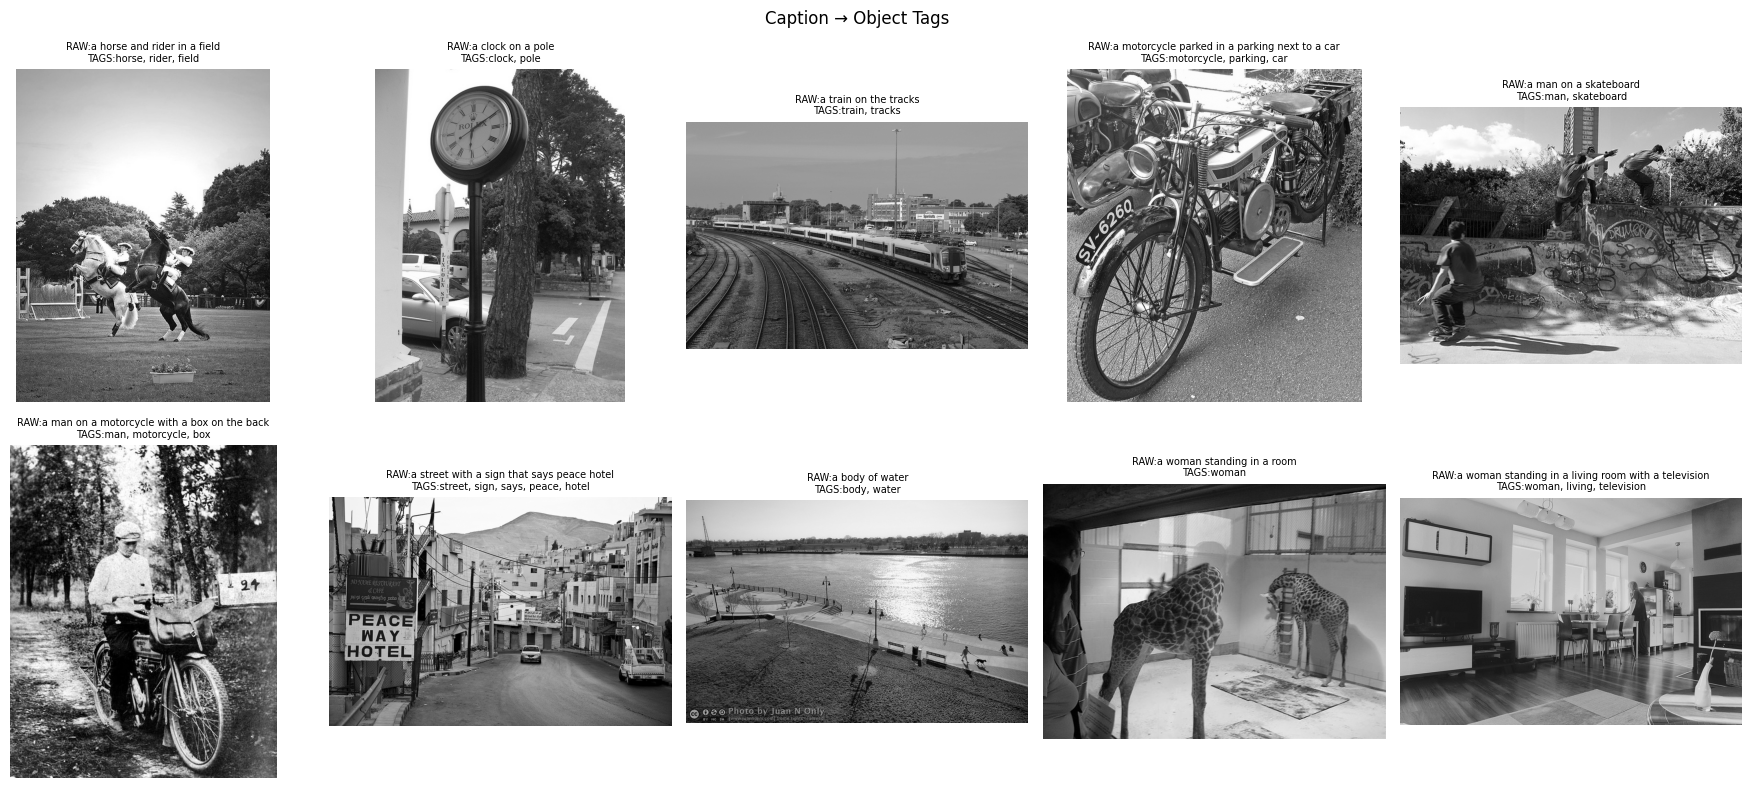

In [ ]:
# Improved caption_to_tags: keeps only object/scene nouns
_STOP=set(("a an the of in on at to and with is are was were that this for it its by from "
"as or be been being do does did has have had will would shall should may might can could "
"not no nor so if but very much more most also just only even still already yet than "
"some any all each every both few many several own other another such "
"here there where when how what which who whom whose why "
"black white photo photograph image picture view shown camera shot scene background "
"foreground side front back top bottom left right center middle large small big little "
"old new first last next long short high low good bad great real close open going sitting "
"standing looking wearing holding playing walking running making taking getting using "
"two three four five group pair set lot number kind type part piece bit way thing "
"day room area place point end line made seen "
"between above below behind along across through around near "
"young different same full empty various about away down into "
"eating flying lying parked covered filled moving turned during").split())

def caption_to_tags(caption):
    """Extract top-8 object/scene nouns from BLIP caption."""
    words=re.findall(r'[a-z]+',caption.lower())
    return ", ".join([w for w in words if w not in _STOP and len(w)>2][:8]) or caption

@torch.no_grad()
def build_text_cache(paths,split_name,device):
    """Build or load token-level text embeddings. Respects CONFIG['cache_text']."""
    cache_path=os.path.join(CONFIG["cache_dir"],f"{split_name}_text_tokens.pt")
    if CONFIG["cache_text"] and os.path.exists(cache_path):
        print(f"Loading cached text: {cache_path}")
        return torch.load(cache_path,map_location="cpu"),[]
    print(f"Computing text embeddings for {split_name} ({len(paths)} images)...")
    cp=BlipProcessor.from_pretrained(CONFIG["caption_model"])
    cm=BlipForConditionalGeneration.from_pretrained(CONFIG["caption_model"]).to(device).eval()
    ct=CLIPTokenizer.from_pretrained(CONFIG["clip_text_model"])
    ce=CLIPTextModel.from_pretrained(CONFIG["clip_text_model"]).to(device).eval()
    cache={};caps=[]
    for i in tqdm(range(len(paths)),desc=f"Caption {split_name}"):
        gray=Image.open(paths[i]).convert("RGB").convert("L").convert("RGB")
        inp=cp(images=gray,return_tensors="pt").to(device)
        ids=cm.generate(**inp,max_new_tokens=CONFIG["caption_max_new_tokens"])
        raw=cp.decode(ids[0],skip_special_tokens=True).strip()
        tags=caption_to_tags(raw);caps.append((i,raw,tags))
        tok=ct([tags],padding="max_length",truncation=True,max_length=CONFIG["max_text_tokens"],return_tensors="pt").to(device)
        out=ce(**tok)
        cache[i]={"tokens":out.last_hidden_state.squeeze(0).cpu().float(),
                  "mask":tok["attention_mask"].squeeze(0).cpu()}
    if CONFIG["cache_text"]:
        torch.save(cache,cache_path);print(f"Saved: {cache_path}")
    return cache,caps

train_tc,train_caps=build_text_cache(train_paths,"train",CONFIG["device"])
val_tc,val_caps=build_text_cache(val_paths,"val",CONFIG["device"])
test_tc,test_caps=build_text_cache(test_paths,"test",CONFIG["device"])
print(f"Text: tr={len(train_tc)} vl={len(val_tc)} te={len(test_tc)}")

# Log 5 example captions+tags
print("\n── Caption → Tag examples ──")
for i,raw,tags in (val_caps or [])[:5]:
    print(f"  [{i}] RAW: {raw}")
    print(f"       TAGS: {tags}")

# Preview grid
prev=(train_caps or [])[:10]
if prev:
    fig,ax=plt.subplots(2,5,figsize=(18,8))
    for a,(i,raw,tags) in zip(ax.flat,prev):
        a.imshow(np.array(Image.open(train_paths[i]).convert("L")),cmap="gray")
        a.set_title(f"RAW:{raw}\nTAGS:{tags}",fontsize=7);a.axis("off")
    plt.suptitle("Caption → Object Tags");plt.tight_layout();plt.show()


In [ ]:
class TDS(Dataset):
    def __init__(s,base,cache,td,mt): s.b,s.c,s.d,s.m=base,cache,td,mt
    def __len__(s): return len(s.b)
    def __getitem__(s,i):
        L,ab,rgb,idx=s.b[i];e=s.c.get(int(idx))
        if e: t,m=e["tokens"][:s.m],e["mask"][:s.m]
        else: t,m=torch.zeros(1,s.d),torch.zeros(1,dtype=torch.long)
        return L,ab,rgb,idx,t,m
def tcf(batch):
    Ls,As,Rs,Is,Ts,Ms=zip(*batch)
    mT=max(t.size(0) for t in Ts);D=Ts[0].size(1)
    tp=torch.zeros(len(batch),mT,D);mp=torch.zeros(len(batch),mT,dtype=torch.long)
    for i,(t,m) in enumerate(zip(Ts,Ms)): T=t.size(0);tp[i,:T]=t;mp[i,:T]=m
    return torch.stack(Ls),torch.stack(As),torch.stack(Rs),torch.tensor(Is),tp,mp

def make_text_loaders(text_dim):
    """Create text-conditioned loaders. CLIP always outputs 512, so text_dim
    is handled inside the model (projection), but we pass full 512 tokens."""
    MT=CONFIG["max_text_tokens"]
    tr=TDS(train_ds,train_tc,512,MT);vl=TDS(val_ds,val_tc,512,MT);te=TDS(test_ds,test_tc,512,MT)
    return (DataLoader(tr,CONFIG["batch_size"],shuffle=True,num_workers=0,pin_memory=True,collate_fn=tcf),
            DataLoader(vl,CONFIG["batch_size"],shuffle=False,num_workers=0,pin_memory=True,collate_fn=tcf),
            DataLoader(te,CONFIG["batch_size"],shuffle=False,num_workers=0,pin_memory=True,collate_fn=tcf))

tr_tl,vl_tl,te_tl=make_text_loaders(512)
print(f"Text loaders ready")


Text loaders ready


In [ ]:
class TextConditionedBlock(nn.Module):
    """Token cross-attention + FiLM at one spatial scale.
    text_in_dim=512 (CLIP), projects to channels internally."""
    def __init__(self,ch,text_in_dim=512,nh=4,use_film=True):
        super().__init__();self.use_film=use_film
        self.norm=nn.GroupNorm(8,ch)
        self.q=nn.Conv2d(ch,ch,1)
        self.text_proj=nn.Linear(text_in_dim,ch*2)  # project CLIP→ch for K,V
        self.attn=nn.MultiheadAttention(ch,nh,batch_first=True)
        self.out=nn.Conv2d(ch,ch,1);self.ln=nn.LayerNorm(ch)
        if use_film:
            self.fg=nn.Linear(text_in_dim,ch);self.fb=nn.Linear(text_in_dim,ch)
            nn.init.zeros_(self.fg.weight);nn.init.zeros_(self.fg.bias)
            nn.init.zeros_(self.fb.weight);nn.init.zeros_(self.fb.bias)
    def forward(self,h,tt,tm=None):
        B,C,H,W=h.shape
        q=self.q(self.norm(h)).view(B,C,H*W).permute(0,2,1)
        kv=self.text_proj(tt);k,v=kv.chunk(2,-1)
        km=(~tm.bool()) if tm is not None else None
        a,_=self.attn(q,k,v,key_padding_mask=km)
        a=self.ln(a).permute(0,2,1).view(B,C,H,W)
        h=h+self.out(a)
        if self.use_film:
            if tm is not None:
                mf=tm.float().unsqueeze(-1);tg=(tt*mf).sum(1)/mf.sum(1).clamp(min=1)
            else: tg=tt.mean(1)
            g=self.fg(tg).unsqueeze(-1).unsqueeze(-1)
            b=self.fb(tg).unsqueeze(-1).unsqueeze(-1)
            h=h*(1+g)+b  # Near-identity: g=0,b=0 at init → h unchanged
        return h

# ── No-VAE baseline (main baseline) ──
class UNetColorizer(nn.Module):
    """Deterministic UNet — no VAE, no text. The primary baseline."""
    def __init__(self,K=5,mode="reg"):
        super().__init__();self.mode,self.K=mode,K
        self.enc1=nn.Conv2d(1,64,4,2,1);self.enc2=nn.Conv2d(64,128,4,2,1)
        self.enc3=nn.Conv2d(128,256,4,2,1);self.enc4=nn.Conv2d(256,512,4,2,1)
        self.up1=nn.ConvTranspose2d(512,256,4,2,1)
        self.up2=nn.ConvTranspose2d(512,128,4,2,1)
        self.up3=nn.ConvTranspose2d(256,64,4,2,1)
        self.up4=nn.ConvTranspose2d(128,2 if mode=="reg" else 5*K,4,2,1)
    def forward(self,L,text_tokens=None,text_mask=None,use_text=False):
        e1=F.leaky_relu(self.enc1(L),.2);e2=F.leaky_relu(self.enc2(e1),.2)
        e3=F.leaky_relu(self.enc3(e2),.2);e4=F.leaky_relu(self.enc4(e3),.2)
        d1=F.relu(self.up1(e4));d2=F.relu(self.up2(torch.cat([d1,e3],1)))
        d3=F.relu(self.up3(torch.cat([d2,e2],1)));out=self.up4(torch.cat([d3,e1],1))
        z=torch.zeros(L.size(0),1,1,1,device=L.device)
        if self.mode=="reg": return {"ab":torch.tanh(out),"mu":z,"logvar":z}
        B,C,H,W=out.shape;K=self.K
        return {"pi":out[:,:K],"mu_mdn":torch.tanh(out[:,K:3*K].view(B,K,2,H,W)),
                "log_sigma":out[:,3*K:].view(B,K,2,H,W),"mu":z,"logvar":z}

# ── Text-conditioned UNet (no VAE, with text) ──
class UNetTextColorizer(nn.Module):
    """UNet + multi-scale TextConditionedBlock. No VAE.
    text_mode: global | token_attn | multiscale | multiscale_film"""
    def __init__(self,text_in_dim=512,K=5,mode="reg",text_mode="multiscale_film"):
        super().__init__();self.mode,self.K,self.text_mode=mode,K,text_mode
        self.enc1=nn.Conv2d(1,64,4,2,1);self.enc2=nn.Conv2d(64,128,4,2,1)
        self.enc3=nn.Conv2d(128,256,4,2,1);self.enc4=nn.Conv2d(256,512,4,2,1)
        self.up1=nn.ConvTranspose2d(512,256,4,2,1)
        self.up2=nn.ConvTranspose2d(512,128,4,2,1)
        self.up3=nn.ConvTranspose2d(256,64,4,2,1)
        # Project CLIP 512 → text_in_dim (identity when text_in_dim==512)
        self.clip_proj=nn.Linear(512,text_in_dim) if text_in_dim!=512 else nn.Identity()
        uf=text_mode in("multiscale_film","global")
        if text_mode in("multiscale","multiscale_film"):
            self.t1=TextConditionedBlock(256,text_in_dim,use_film=uf)
            self.t2=TextConditionedBlock(128,text_in_dim,use_film=uf)
            self.t3=TextConditionedBlock(64,text_in_dim,use_film=uf)
        elif text_mode=="token_attn":
            self.t1=TextConditionedBlock(256,text_in_dim,use_film=False)
        elif text_mode=="global":
            for ch,nm in[(256,"f1"),(128,"f2"),(64,"f3")]:
                f=nn.ModuleDict({"g":nn.Linear(text_in_dim,ch),"b":nn.Linear(text_in_dim,ch)})
                nn.init.zeros_(f["g"].weight);nn.init.zeros_(f["g"].bias)
                nn.init.zeros_(f["b"].weight);nn.init.zeros_(f["b"].bias)
                setattr(self,nm,f)
        self.up4=nn.ConvTranspose2d(128,2 if mode=="reg" else 5*K,4,2,1)
    def _tg(self,tt,tm):
        if tm is not None:
            mf=tm.float().unsqueeze(-1);return(tt*mf).sum(1)/mf.sum(1).clamp(min=1)
        return tt.mean(1)
    def _af(self,h,f,tg):
        return h*(1+f["g"](tg).unsqueeze(-1).unsqueeze(-1))+f["b"](tg).unsqueeze(-1).unsqueeze(-1)
    def forward(self,L,text_tokens=None,text_mask=None,use_text=False):
        ht=use_text and text_tokens is not None
        # Project CLIP tokens 512→text_in_dim before any text conditioning
        if ht and text_tokens is not None:text_tokens=self.clip_proj(text_tokens)
        e1=F.leaky_relu(self.enc1(L),.2);e2=F.leaky_relu(self.enc2(e1),.2)
        e3=F.leaky_relu(self.enc3(e2),.2);e4=F.leaky_relu(self.enc4(e3),.2)
        d1=F.relu(self.up1(e4))
        if ht:
            if self.text_mode in("multiscale","multiscale_film","token_attn"):d1=self.t1(d1,text_tokens,text_mask)
            elif self.text_mode=="global":d1=self._af(d1,self.f1,self._tg(text_tokens,text_mask))
        d2=F.relu(self.up2(torch.cat([d1,e3],1)))
        if ht and self.text_mode in("multiscale","multiscale_film"):d2=self.t2(d2,text_tokens,text_mask)
        elif ht and self.text_mode=="global":d2=self._af(d2,self.f2,self._tg(text_tokens,text_mask))
        d3=F.relu(self.up3(torch.cat([d2,e2],1)))
        if ht and self.text_mode in("multiscale","multiscale_film"):d3=self.t3(d3,text_tokens,text_mask)
        elif ht and self.text_mode=="global":d3=self._af(d3,self.f3,self._tg(text_tokens,text_mask))
        out=self.up4(torch.cat([d3,e1],1))
        z=torch.zeros(L.size(0),1,1,1,device=L.device)
        if self.mode=="reg": return {"ab":torch.tanh(out),"mu":z,"logvar":z}
        B,C,H,W=out.shape;K=self.K
        return {"pi":out[:,:K],"mu_mdn":torch.tanh(out[:,K:3*K].view(B,K,2,H,W)),
                "log_sigma":out[:,3*K:].view(B,K,2,H,W),"mu":z,"logvar":z}

class PatchGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(4,64,4,2,1)),nn.LeakyReLU(.2),
            nn.utils.spectral_norm(nn.Conv2d(64,128,4,2,1)),nn.LeakyReLU(.2),
            nn.utils.spectral_norm(nn.Conv2d(128,256,4,2,1)),nn.LeakyReLU(.2),
            nn.Conv2d(256,1,4,1,1))
    def forward(self,L,rgb): return self.net(torch.cat([L,rgb],1))
print("Models: UNetColorizer (no-VAE), UNetTextColorizer (text modes), PatchGAN")


Models: UNetColorizer (no-VAE), UNetTextColorizer (text modes), PatchGAN


In [ ]:
def _ub(batch,ut,dev):
    if len(batch)==6:
        L,ab,rgb,idx,t,m=batch;L,ab,rgb=L.to(dev),ab.to(dev),rgb.to(dev)
        return L,ab,rgb,(t.to(dev) if ut else None),(m.to(dev) if ut else None)
    L,ab,rgb,idx=batch;return L.to(dev),ab.to(dev),rgb.to(dev),None,None

def val_epoch(G,mode,ut,loader,lpfn,dev):
    """Validate on val set (EVAL ONLY — uses NumPy Lab→RGB)."""
    G.eval();psnr=PeakSignalNoiseRatio(data_range=1.0).to(dev)
    ssim=StructuralSimilarityIndexMeasure(data_range=1.0).to(dev)
    l1s,lps,des,cls,nlls=[],[],[],[],[]
    with torch.no_grad():
        for b in loader:
            L,ab,rgb,tk,mk=_ub(b,ut,dev)
            out=G(L,text_tokens=tk,text_mask=mk,use_text=ut)
            ap=out["ab"] if mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
            l1s.append(F.l1_loss(ap,ab).item())
            cls.append(chroma_loss(ap,ab).item())
            if mode=="mdn":
                nlls.append(mdn_nll(out["pi"],out["mu_mdn"],out["log_sigma"],ab,CONFIG["mdn_min_sigma"]).item())
            rp=lab_to_rgb_np(L,ap).clamp(0,1)  # NumPy: eval only, no grad
            if torch.isnan(rp).any(): continue
            psnr.update(rp,rgb);ssim.update(rp,rgb)
            lps.append(lpfn(rp*2-1,rgb*2-1).mean().item())
            des.append(ciede2000_batch(L,ab,ap))
    r={"val_l1":np.mean(l1s)if l1s else 999,"val_psnr":float(psnr.compute().item()),
       "val_ssim":float(ssim.compute().item()),"val_lpips":np.mean(lps)if lps else 999,
       "val_deltae":np.mean(des)if des else 999,"val_chroma":np.mean(cls)if cls else 999}
    if mode=="mdn":
        r["val_nll"]=np.mean(nlls) if nlls else 999
    return r

def run_experiment(name,mode,ut,tm,trl,vll,tel,dev,use_vae=False,text_in_dim=512,lambda_chroma=0.0):
    seed_all(CONFIG["seed"])
    print(f"\n{'='*60}\n  {name} | mode={mode} | text_mode={tm} | vae={use_vae} | text_dim={text_in_dim} | lam_chroma={lambda_chroma}\n{'='*60}")
    rd=os.path.join(CONFIG["save_dir"],name);os.makedirs(rd,exist_ok=True)
    cs={k:str(v) if not isinstance(v,(int,float,bool,str,list,dict,type(None))) else v for k,v in CONFIG.items()}
    cs.update({"experiment":name,"mode":mode,"text_mode":tm,"use_vae":use_vae,"text_in_dim":text_in_dim,"lambda_chroma":lambda_chroma})
    with open(os.path.join(rd,"config.json"),"w") as f: json.dump(cs,f,indent=2)

    if not ut:
        G=UNetColorizer(K=CONFIG["mdn_K"],mode=mode).to(dev)
    else:
        G=UNetTextColorizer(text_in_dim=text_in_dim,K=CONFIG["mdn_K"],mode=mode,text_mode=tm).to(dev)
    D=PatchGAN().to(dev)
    lr_g=CONFIG["lr_g_mdn"] if mode=="mdn" else CONFIG["lr_g_reg"]
    oG=torch.optim.Adam(G.parameters(),lr=lr_g,betas=(.5,.999))
    oD=torch.optim.Adam(D.parameters(),lr=CONFIG["lr_d"],betas=(.5,.999))
    sG=torch.optim.lr_scheduler.CosineAnnealingLR(oG,CONFIG["epochs"])
    sD=torch.optim.lr_scheduler.CosineAnnealingLR(oD,CONFIG["epochs"])
    bce=nn.BCEWithLogitsLoss();lpfn=lpips.LPIPS(net='alex').to(dev)
    la=CONFIG["lambda_adv_mdn"] if mode=="mdn" else CONFIG["lambda_adv_reg"]
    lr_c=CONFIG["lambda_recon_mdn"] if mode=="mdn" else CONFIG["lambda_recon_reg"]
    hist=[];bvl,bst,pat=float('inf'),None,0

    for ep in range(CONFIG["epochs"]):
        G.train();D.train()
        wk="gan_warmup_epochs_mdn" if mode=="mdn" else "gan_warmup_epochs_reg"
        gon=ep>=CONFIG.get(wk,0)
        # Per-epoch loss accumulators
        sum_rc,sum_adv,sum_lp,sum_mdn,sum_chroma,nb=0,0,0,0,0,0

        for batch in tqdm(trl,desc=f"{name} ep{ep+1}",leave=False):
            L,ab,rgb,tk,mk=_ub(batch,ut,dev)
            if gon:
                oD.zero_grad(set_to_none=True)
                with torch.no_grad():
                    od=G(L,text_tokens=tk,text_mask=mk,use_text=ut)
                    af=od["ab"] if mode=="reg" else mdn_expected_ab(od["pi"],od["mu_mdn"])
                    # TRAINING: differentiable Lab→RGB for D backward
                    rf=lab_to_rgb_diff(L,af)
                ld=.5*(bce(D(L,rgb),torch.ones_like(D(L,rgb))*.9)+bce(D(L,rf),torch.zeros_like(D(L,rf))))
                if torch.isfinite(ld):ld.backward();oD.step()
                else:continue
            oG.zero_grad(set_to_none=True)
            out=G(L,text_tokens=tk,text_mask=mk,use_text=ut)
            if mode=="reg":
                ap=out["ab"];rc=F.l1_loss(ap,ab);mdn_l=torch.tensor(0.)
            else:
                mdn_l=mdn_nll(out["pi"],out["mu_mdn"],out["log_sigma"],ab,CONFIG["mdn_min_sigma"])
                ap=mdn_expected_ab(out["pi"],out["mu_mdn"]);rc=mdn_l
            if torch.isnan(ap).any():continue
            # TRAINING: differentiable Lab→RGB for LPIPS + adversarial G loss
            rp=lab_to_rgb_diff(L,ap)
            adv=bce(D(L,rp),torch.ones_like(D(L,rp))) if gon else torch.tensor(0.,device=dev)
            lp=lpfn(rp*2-1,rgb*2-1).mean() if CONFIG["lambda_lpips"]>0 else torch.tensor(0.,device=dev)
            lc=chroma_loss(ap,ab) if lambda_chroma>0 else torch.tensor(0.,device=dev)
            lG=lr_c*rc+la*adv+CONFIG["lambda_lpips"]*lp+lambda_chroma*lc
            if not torch.isfinite(lG):continue
            lG.backward();nn.utils.clip_grad_norm_(G.parameters(),CONFIG["clip_grad"]);oG.step()
            sum_rc+=rc.item();sum_adv+=adv.item();sum_lp+=lp.item()
            sum_mdn+=mdn_l.item() if mode=="mdn" else 0;sum_chroma+=lc.item();nb+=1
        sG.step();sD.step()

        # ── Per-epoch loss magnitudes ──
        n=max(nb,1)
        loss_mag={"recon":sum_rc/n,"adv":sum_adv/n,"lpips":sum_lp/n,"mdn_nll":sum_mdn/n,"chroma":sum_chroma/n}
        vm=val_epoch(G,mode,ut,vll,lpfn,dev)
        row={"epoch":ep+1,**{f"train_{k}":v for k,v in loss_mag.items()},**vm}
        hist.append(row)
        print(f"  ep{ep+1} LOSS: rc={loss_mag['recon']:.4f} adv={loss_mag['adv']:.4f} lpips={loss_mag['lpips']:.4f} mdn={loss_mag['mdn_nll']:.4f} chroma={loss_mag['chroma']:.4f}")
        val_line=f"         VAL:  psnr={vm['val_psnr']:.2f} ssim={vm['val_ssim']:.4f} lpips={vm['val_lpips']:.4f} dE={vm['val_deltae']:.2f} chroma={vm['val_chroma']:.4f}"
        if mode=="mdn": val_line+=f" nll={vm.get('val_nll',0):.4f}"
        print(val_line)

        # Best-checkpoint selection: val_nll for MDN, val_l1 for deterministic
        if CONFIG.get("early_stopping"):
            ckpt_metric=vm.get("val_nll",999) if mode=="mdn" else vm["val_l1"]
            if ckpt_metric<bvl-CONFIG.get("es_min_delta",0):
                bvl=ckpt_metric;bst=copy.deepcopy(G.state_dict());pat=0
                torch.save(bst,os.path.join(rd,"best_val_checkpoint.pt"))
            else:pat+=1
            if pat>=CONFIG["es_patience"]:print(f"  ** Early stop ep{ep+1}");break
    if CONFIG.get("early_stopping") and bst:G.load_state_dict(bst)
    torch.save(G.state_dict(),os.path.join(rd,"final_checkpoint.pt"))
    viz_bundle={
        "experiment":name,
        "mode":mode,
        "use_text":ut,
        "text_mode":tm,
        "text_in_dim":text_in_dim,
        "mdn_K":CONFIG["mdn_K"],
        "state_dict":G.state_dict(),
    }
    torch.save(viz_bundle,os.path.join(rd,"viz_model_bundle.pt"))
    pd.DataFrame(hist).to_csv(os.path.join(rd,"metrics_history.csv"),index=False)
    print(f"  Saved checkpoints: final_checkpoint.pt + viz_model_bundle.pt")

    # ── Final TEST (used once per experiment) ──
    G.eval();psnr=PeakSignalNoiseRatio(data_range=1.0).to(dev)
    ssim=StructuralSimilarityIndexMeasure(data_range=1.0).to(dev)
    fid=FrechetInceptionDistance(feature=2048).to(dev)  # FID-2048: standard InceptionV3 pool3
    lps,des,c_prs,c_gts=[],[],[],[]
    with torch.no_grad():
        for bi,b in enumerate(tqdm(tel,desc=f"Test {name}")):
            if CONFIG.get("eval_max_batches") and bi>=CONFIG["eval_max_batches"]:break
            L,ab,rgb,tk,mk=_ub(b,ut,dev)
            out=G(L,text_tokens=tk,text_mask=mk,use_text=ut)
            ap=out["ab"] if mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
            rp=lab_to_rgb_np(L,ap).clamp(0,1)  # NumPy: eval only
            if torch.isnan(rp).any():continue
            psnr.update(rp,rgb);ssim.update(rp,rgb)
            fid.update(to_uint8(rgb),real=True);fid.update(to_uint8(rp),real=False)
            lps.append(lpfn(rp*2-1,rgb*2-1).mean().item())
            des.append(ciede2000_batch(L,ab,ap))
            c_prs.append(torch.sqrt(ap[:,0:1]**2+ap[:,1:2]**2+1e-8).mean().item())
            c_gts.append(torch.sqrt(ab[:,0:1]**2+ab[:,1:2]**2+1e-8).mean().item())
    cr=np.mean(c_prs)/max(np.mean(c_gts),1e-6) if c_gts else 0
    tm_r={"psnr":float(psnr.compute().item()),"ssim":float(ssim.compute().item()),
          "fid_2048":float(fid.compute().item()),
          "lpips":float(np.mean(lps))if lps else 0,"delta_e":float(np.mean(des))if des else 0,
          "chroma_ratio":float(cr),"model":G}
    ts={k:v for k,v in tm_r.items() if k!="model"}
    with open(os.path.join(rd,"test_metrics.json"),"w") as f:json.dump(ts,f,indent=2)

    # ── Save qualitative grid for this experiment ──
    try:
        G.eval();qb=next(iter(tel));qL,qab,qrgb,qtk,qmk=_ub(qb,ut,dev)
        qL,qab,qrgb=qL[:6],qab[:6],qrgb[:6]
        if qtk is not None:qtk,qmk=qtk[:6],qmk[:6]
        with torch.no_grad():
            qout=G(qL,text_tokens=qtk if ut else None,text_mask=qmk if ut else None,use_text=ut)
            qap=qout["ab"] if mode=="reg" else mdn_expected_ab(qout["pi"],qout["mu_mdn"])
            qrp=lab_to_rgb_np(qL,qap).clamp(0,1)
        fig_q,ax_q=plt.subplots(6,3,figsize=(9,18),squeeze=False)
        for qi in range(min(6,qL.size(0))):
            ax_q[qi,0].imshow(qL[qi,0].cpu().numpy(),cmap="gray");ax_q[qi,0].axis("off");ax_q[qi,0].set_title("L")
            ax_q[qi,1].imshow(qrgb[qi].permute(1,2,0).cpu().numpy());ax_q[qi,1].axis("off");ax_q[qi,1].set_title("GT")
            ax_q[qi,2].imshow(qrp[qi].permute(1,2,0).cpu().numpy());ax_q[qi,2].axis("off");ax_q[qi,2].set_title(name)
        plt.suptitle(f"Qualitative: {name}");plt.tight_layout()
        fig_q.savefig(os.path.join(rd,"qualitative_grid.png"),dpi=150,bbox_inches="tight");plt.close(fig_q)
    except Exception as e: print(f"  qualitative grid skipped: {e}")

    # ── Save chroma histogram for this experiment ──
    try:
        d=chroma_diagnostics(qab,qap)
        fig_h,ax_h=plt.subplots(1,3,figsize=(15,4))
        ax_h[0].hist(d["a_gt"],bins=60,alpha=.5,label="GT",density=True)
        ax_h[0].hist(d["a_pr"],bins=60,alpha=.5,label="Pred",density=True);ax_h[0].set_title("a channel");ax_h[0].legend()
        ax_h[1].hist(d["b_gt"],bins=60,alpha=.5,label="GT",density=True)
        ax_h[1].hist(d["b_pr"],bins=60,alpha=.5,label="Pred",density=True);ax_h[1].set_title("b channel");ax_h[1].legend()
        ax_h[2].hist(d["chroma_gt"],bins=60,alpha=.5,label="GT",density=True)
        ax_h[2].hist(d["chroma_pr"],bins=60,alpha=.5,label="Pred",density=True)
        ax_h[2].set_title(f"Chroma C (ratio={d['chroma_ratio']:.3f})");ax_h[2].legend()
        plt.suptitle(f"Chroma Histogram: {name}");plt.tight_layout()
        fig_h.savefig(os.path.join(rd,"chroma_histogram.png"),dpi=150,bbox_inches="tight");plt.close(fig_h)
    except Exception as e: print(f"  chroma histogram skipped: {e}")

    print(f"  TEST: {ts}");return tm_r


In [ ]:
device=CONFIG["device"];R={}

# ── Core ablation table (4 experiments) ──

# 1. Baseline: deterministic UNet, no text conditioning
R["baseline"]=run_experiment(
    "baseline","reg",False,"none",
    train_loader,val_loader,test_loader,device,
    use_vae=False
)

# 2. Ours: + caption cross-attention (token-level)
R["ours"]=run_experiment(
    "ours","reg",True,"token_attn",
    tr_tl,vl_tl,te_tl,device,
    use_vae=False
)

# 3. Ours + Lc: + chroma-aware loss
R["ours_chroma"]=run_experiment(
    "ours_chroma","reg",True,"token_attn",
    tr_tl,vl_tl,te_tl,device,
    use_vae=False,lambda_chroma=CONFIG["lambda_chroma"]
)

# 4. Ours + MDN: probabilistic color prediction
R["ours_mdn"]=run_experiment(
    "ours_mdn","mdn",True,"multiscale_film",
    tr_tl,vl_tl,te_tl,device,
    use_vae=False
)



  baseline | mode=reg | text_mode=none | vae=False | text_dim=512 | lam_chroma=0.0
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


baseline ep1:   0%|          | 0/3329 [00:00<?, ?it/s]

/tmp/ipykernel_796/1708664240.py:93: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sG.step();sD.step()


...

  ep38 LOSS: rc=-3.3997 adv=5.1050 lpips=0.1524 mdn=-3.3997 chroma=0.0000
         VAL:  psnr=22.64 ssim=0.9288 lpips=0.1631 dE=8.94 chroma=0.0700 nll=-3.0564


ours_mdn ep39:   0%|          | 0/3329 [00:00<?, ?it/s]

  ep39 LOSS: rc=-3.4096 adv=5.1178 lpips=0.1521 mdn=-3.4096 chroma=0.0000
         VAL:  psnr=22.64 ssim=0.9297 lpips=0.1633 dE=8.97 chroma=0.0709 nll=-3.0738
  ** Early stop ep39
  Saved checkpoints: final_checkpoint.pt + viz_model_bundle.pt


Test ours_mdn:   0%|          | 0/714 [00:00<?, ?it/s]

  TEST: {'psnr': 22.527225494384766, 'ssim': 0.9273125529289246, 'fid_2048': 55.80922317504883, 'lpips': 0.16421146899461747, 'delta_e': 9.022818021774292, 'chroma_ratio': 0.6377530208535526}


In [ ]:
rows=[]
for k,v in R.items():
    rows.append({"experiment":k,"PSNR":f"{v['psnr']:.2f}","SSIM":f"{v['ssim']:.4f}",
        "LPIPS↓":f"{v['lpips']:.4f}","ΔE↓":f"{v['delta_e']:.2f}",
        "FID↓ (2048)":f"{v['fid_2048']:.1f}",
        "Chroma↑":f"{v.get('chroma_ratio',0):.3f}"})
df=pd.DataFrame(rows)
print("FID: InceptionV3 feature=2048 (standard pool3, NOT reduced).")
print("LPIPS: AlexNet backbone, reported as eval metric.\n")
print(df.to_string(index=False))

# ── Text Effect table ──
print("\n── Text Effect: Baseline → Ours → +Chroma ──")
te_keys=[k for k in ["baseline","ours","ours_chroma"] if k in R]
te_rows=[{"experiment":k,"PSNR":f"{R[k]['psnr']:.2f}","SSIM":f"{R[k]['ssim']:.4f}",
    "ΔE↓":f"{R[k]['delta_e']:.2f}","Chroma↑":f"{R[k].get('chroma_ratio',0):.3f}"}
    for k in te_keys]
if te_rows: print(pd.DataFrame(te_rows).to_string(index=False))

# ── Probabilistic Decoding table ──
print("\n── Probabilistic Decoding: reg vs MDN ──")
pd_keys=[k for k in ["ours","ours_chroma","ours_mdn"] if k in R]
pd_rows=[{"experiment":k,"PSNR":f"{R[k]['psnr']:.2f}","ΔE↓":f"{R[k]['delta_e']:.2f}",
    "FID↓":f"{R[k]['fid_2048']:.1f}","Chroma↑":f"{R[k].get('chroma_ratio',0):.3f}"}
    for k in pd_keys]
if pd_rows: print(pd.DataFrame(pd_rows).to_string(index=False))


In [ ]:
# ── Build fixed evaluation panel (8-12 images across semantic categories) ──
dev=CONFIG["device"]
PANEL_CATS={"sky":["sky","cloud","clouds","sunset","sunrise","horizon"],
    "vegetation":["grass","tree","trees","forest","garden","plant","leaves","flower"],
    "snow":["snow","mountain","ice","winter","frozen"],
    "animals":["dog","cat","horse","bird","cow","sheep","elephant","bear","animal"],
    "urban":["street","building","city","road","traffic","bus","car","bridge"]}
panel_idx=[]
if test_caps:
    for cat,kws in PANEL_CATS.items():
        found_c=[]
        for ci,(_,raw,tags) in enumerate(test_caps):
            if any(k in tags.lower() for k in kws) and ci not in panel_idx:
                found_c.append(ci)
            if len(found_c)>=2: break
        panel_idx.extend(found_c[:2])
if len(panel_idx)<8:
    extra=[i for i in range(min(50,len(test_paths))) if i not in panel_idx]
    panel_idx.extend(extra[:8-len(panel_idx)])
panel_idx=panel_idx[:12]
print(f"Fixed evaluation panel: {len(panel_idx)} images")

# Load panel images as tensors
S=CONFIG["img_size"]
pL,pAB,pRGB,pTK,pMK=[],[],[],[],[]
for pi in panel_idx:
    img=Image.open(test_paths[pi]).convert("RGB").resize((S,S))
    rgb_np=np.array(img).astype(np.float32)/255;lab=skcolor.rgb2lab(rgb_np)
    pL.append(torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float())
    pAB.append(torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float())
    pRGB.append(torch.from_numpy(rgb_np).permute(2,0,1).float())
    e=test_tc.get(pi)
    if e: pTK.append(e["tokens"]);pMK.append(e["mask"])
    else: pTK.append(torch.zeros(1,512));pMK.append(torch.zeros(1,dtype=torch.long))
pL=torch.stack(pL).to(dev);pAB=torch.stack(pAB).to(dev);pRGB=torch.stack(pRGB).to(dev)
mT=max(t.size(0) for t in pTK)
pTP=torch.zeros(len(panel_idx),mT,512);pMP=torch.zeros(len(panel_idx),mT,dtype=torch.long)
for i,(t,m) in enumerate(zip(pTK,pMK)):T=t.size(0);pTP[i,:T]=t;pMP[i,:T]=m
pTP=pTP.to(dev);pMP=pMP.to(dev)

# ── Main comparison grid: Grayscale → GT → Baseline → Caption → Caption+Chroma (+MDN) ──
core_models=[(k,R[k]["model"],k!="baseline") for k in ["baseline","ours","ours_chroma"] if k in R]
mdn_key_p="ours_mdn" if "ours_mdn" in R else None
ncols_main=2+len(core_models)+(2 if mdn_key_p else 0)
col_main=["Grayscale","Ground Truth"]+["Baseline","Ours","Ours + Lc"][:len(core_models)]+(["MDN expected","MDN sampled"] if mdn_key_p else [])
n_p=len(panel_idx)
fig,axes=plt.subplots(n_p,ncols_main,figsize=(3*ncols_main,3*n_p))
if n_p==1:axes=axes[np.newaxis,:]
for i in range(n_p):
    axes[i,0].imshow(pL[i,0].cpu().numpy(),cmap="gray");axes[i,0].axis("off")
    axes[i,1].imshow(pRGB[i].permute(1,2,0).cpu().numpy());axes[i,1].axis("off")
    for j,(mn,M,ut) in enumerate(core_models):
        M.eval()
        with torch.no_grad():
            out=M(pL[i:i+1],text_tokens=pTP[i:i+1] if ut else None,
                  text_mask=pMP[i:i+1] if ut else None,use_text=ut)
            ap=out["ab"];rp=lab_to_rgb_np(pL[i:i+1],ap).clamp(0,1)
        axes[i,2+j].imshow(rp[0].permute(1,2,0).cpu().numpy());axes[i,2+j].axis("off")
    if mdn_key_p:
        Mm=R[mdn_key_p]["model"];Mm.eval()
        with torch.no_grad():
            om=Mm(pL[i:i+1],text_tokens=pTP[i:i+1],text_mask=pMP[i:i+1],use_text=True)
            rpe=lab_to_rgb_np(pL[i:i+1],mdn_expected_ab(om["pi"],om["mu_mdn"])).clamp(0,1)
            rps=lab_to_rgb_np(pL[i:i+1],mdn_sample_ab(om["pi"],om["mu_mdn"],om["log_sigma"],1.0)).clamp(0,1)
        ci=2+len(core_models)
        axes[i,ci].imshow(rpe[0].permute(1,2,0).cpu().numpy());axes[i,ci].axis("off")
        axes[i,ci+1].imshow(rps[0].permute(1,2,0).cpu().numpy());axes[i,ci+1].axis("off")
for j,t in enumerate(col_main):axes[0,j].set_title(t,fontsize=9)
plt.suptitle("Main Comparison — Fixed Evaluation Panel",fontsize=14);plt.tight_layout();plt.show()
fig.savefig(os.path.join(CONFIG["save_dir"],"main_comparison_grid.png"),dpi=150,bbox_inches="tight")

# ── Chroma recovery visualization: Ours vs Ours + Lc on fixed panel ──
if "ours" in R and "ours_chroma" in R:
    M_ta=R["ours"]["model"];M_tc=R["ours_chroma"]["model"]
    M_ta.eval();M_tc.eval()
    fig_cr,ax_cr=plt.subplots(n_p,4,figsize=(12,3*n_p),squeeze=False)
    for i in range(n_p):
        ax_cr[i,0].imshow(pL[i,0].cpu().numpy(),cmap="gray");ax_cr[i,0].axis("off")
        ax_cr[i,1].imshow(pRGB[i].permute(1,2,0).cpu().numpy());ax_cr[i,1].axis("off")
        with torch.no_grad():
            o1=M_ta(pL[i:i+1],text_tokens=pTP[i:i+1],text_mask=pMP[i:i+1],use_text=True)
            o2=M_tc(pL[i:i+1],text_tokens=pTP[i:i+1],text_mask=pMP[i:i+1],use_text=True)
            r1=lab_to_rgb_np(pL[i:i+1],o1["ab"]).clamp(0,1)
            r2=lab_to_rgb_np(pL[i:i+1],o2["ab"]).clamp(0,1)
        ax_cr[i,2].imshow(r1[0].permute(1,2,0).cpu().numpy());ax_cr[i,2].axis("off")
        ax_cr[i,3].imshow(r2[0].permute(1,2,0).cpu().numpy());ax_cr[i,3].axis("off")
    for j,t in enumerate(["L","GT","Ours","Ours + Lc"]):ax_cr[0,j].set_title(t,fontsize=9)
    plt.suptitle("Chroma Recovery: Effect of Chroma-Aware Loss",fontsize=14);plt.tight_layout();plt.show()
    fig_cr.savefig(os.path.join(CONFIG["save_dir"],"chroma_recovery.png"),dpi=150,bbox_inches="tight")

# ── Caption guidance examples on fixed panel ──
if "baseline" in R and "ours" in R:
    M_nv=R["baseline"]["model"];M_tx=R["ours"]["model"]
    M_nv.eval();M_tx.eval()
    fig_cg,ax_cg=plt.subplots(n_p,4,figsize=(12,3*n_p),squeeze=False)
    for i in range(n_p):
        ax_cg[i,0].imshow(pL[i,0].cpu().numpy(),cmap="gray");ax_cg[i,0].axis("off")
        ax_cg[i,1].imshow(pRGB[i].permute(1,2,0).cpu().numpy());ax_cg[i,1].axis("off")
        with torch.no_grad():
            onv=M_nv(pL[i:i+1],use_text=False)
            otx=M_tx(pL[i:i+1],text_tokens=pTP[i:i+1],text_mask=pMP[i:i+1],use_text=True)
            rnv=lab_to_rgb_np(pL[i:i+1],onv["ab"]).clamp(0,1)
            rtx=lab_to_rgb_np(pL[i:i+1],otx["ab"]).clamp(0,1)
        ax_cg[i,2].imshow(rnv[0].permute(1,2,0).cpu().numpy());ax_cg[i,2].axis("off")
        ax_cg[i,3].imshow(rtx[0].permute(1,2,0).cpu().numpy());ax_cg[i,3].axis("off")
    for j,t in enumerate(["L","GT","Baseline","Ours"]):ax_cg[0,j].set_title(t,fontsize=9)
    plt.suptitle("Caption Guidance: Baseline vs Text-Conditioned",fontsize=14);plt.tight_layout();plt.show()
    fig_cg.savefig(os.path.join(CONFIG["save_dir"],"caption_guidance.png"),dpi=150,bbox_inches="tight")

print(f"Saved main_comparison_grid.png, chroma_recovery.png, caption_guidance.png")


In [ ]:
mdn_key="ours_mdn"
mdn_M=R[mdn_key]["model"];mdn_M.eval();dev=CONFIG["device"]
b=next(iter(te_tl));L,ab,rgb,tk,mk=_ub(b,True,dev)
L,ab,rgb=L[:4],ab[:4],rgb[:4]
if tk is not None:tk,mk=tk[:4],mk[:4]
with torch.no_grad():
    out=mdn_M(L,text_tokens=tk,text_mask=mk,use_text=True)
    ab_exp=mdn_expected_ab(out["pi"],out["mu_mdn"])
    ab_map=mdn_map_ab(out["pi"],out["mu_mdn"])
    ab_bon=mdn_best_of_n(out["pi"],out["mu_mdn"],out["log_sigma"],L,ab,CONFIG["mdn_best_of_n"])
    ab_samp={t:mdn_sample_ab(out["pi"],out["mu_mdn"],out["log_sigma"],t) for t in CONFIG["mdn_temperatures"]}

cols=4+len(CONFIG["mdn_temperatures"]);n=4
fig,ax=plt.subplots(n,cols,figsize=(3*cols,3*n))
titles=["GT","Expected","MAP","Best-of-N"]+[f"T={t}" for t in CONFIG["mdn_temperatures"]]
for i in range(n):
    ax[i,0].imshow(rgb[i].permute(1,2,0).cpu().numpy())
    ax[i,1].imshow(lab_to_rgb_np(L[i:i+1],ab_exp[i:i+1]).squeeze().permute(1,2,0).cpu().numpy())
    ax[i,2].imshow(lab_to_rgb_np(L[i:i+1],ab_map[i:i+1]).squeeze().permute(1,2,0).cpu().numpy())
    ax[i,3].imshow(lab_to_rgb_np(L[i:i+1],ab_bon[i:i+1]).squeeze().permute(1,2,0).cpu().numpy())
    for j,t in enumerate(CONFIG["mdn_temperatures"]):
        ax[i,4+j].imshow(lab_to_rgb_np(L[i:i+1],ab_samp[t][i:i+1]).squeeze().permute(1,2,0).cpu().numpy())
    for a in ax[i]:a.axis("off")
for j,t in enumerate(titles):ax[0,j].set_title(t,fontsize=8)
plt.suptitle(f"MDN Decoding ({mdn_key}): Expected vs MAP vs Best-of-N vs Samples");plt.tight_layout();plt.show()

# ── Chroma comparison across ALL decoding modes ──
decode_abs={"GT":ab,"Expected":ab_exp,"MAP":ab_map,"Best-of-N":ab_bon,"Sample(T=1)":ab_samp[1.0]}
c_gt_ref=np.sqrt((ab[:,0]**2+ab[:,1]**2).mean().item())*128
print(f"\n── Chroma per decoding mode ({mdn_key}) ──")
chroma_table=[]
for dname,dab in decode_abs.items():
    c=np.sqrt((dab[:,0]**2+dab[:,1]**2).mean().item())*128
    chroma_table.append({"decode":dname,"mean_chroma":f"{c:.1f}","ratio_to_GT":f"{c/max(c_gt_ref,1e-6):.3f}"})
print(pd.DataFrame(chroma_table).to_string(index=False))

# ── Full metrics table per decoding mode (PSNR, SSIM, LPIPS, ΔE, chroma) ──
lpfn_m=lpips.LPIPS(net='alex').to(dev)
print(f"\n── Full metrics by decoding mode ({mdn_key}) ──")
decode_metrics=[]
for dname,dab in decode_abs.items():
    if dname=="GT": continue
    rp=lab_to_rgb_np(L,dab).clamp(0,1)
    if torch.isnan(rp).any(): continue
    dp=PeakSignalNoiseRatio(data_range=1.0).to(dev);dp.update(rp,rgb)
    ds=StructuralSimilarityIndexMeasure(data_range=1.0).to(dev);ds.update(rp,rgb)
    dl=lpfn_m(rp*2-1,rgb*2-1).mean().item()
    dd=ciede2000_batch(L,ab,dab)
    cr_d=np.sqrt((dab[:,0]**2+dab[:,1]**2).mean().item())*128/max(c_gt_ref,1e-6)
    decode_metrics.append({"decode":dname,"PSNR":f"{dp.compute().item():.2f}",
        "SSIM":f"{ds.compute().item():.4f}","LPIPS":f"{dl:.4f}",
        "ΔE":f"{dd:.2f}","chroma_ratio":f"{cr_d:.3f}"})
print(pd.DataFrame(decode_metrics).to_string(index=False))

# Diversity: pairwise LPIPS
lpfn2=lpips.LPIPS(net='alex').to(dev);ns=5
with torch.no_grad():
    ss=[lab_to_rgb_diff(L,mdn_sample_ab(out["pi"],out["mu_mdn"],out["log_sigma"],1.0)) for _ in range(ns)]
    pw=[lpfn2(ss[i]*2-1,ss[j]*2-1).mean().item() for i in range(ns) for j in range(i+1,ns)]
print(f"\nMDN diversity (pairwise LPIPS, {ns} samples): {np.mean(pw):.4f} ± {np.std(pw):.4f}")

# ── Stability check: do sampled outputs improve color without becoming unstable? ──
print(f"\n── Sampled output stability check ──")
n_stability=10
stab_psnrs,stab_lpips_vals=[],[]
with torch.no_grad():
    for si in range(n_stability):
        s_ab=mdn_sample_ab(out["pi"],out["mu_mdn"],out["log_sigma"],1.0)
        s_rp=lab_to_rgb_np(L,s_ab).clamp(0,1)
        if torch.isnan(s_rp).any():
            stab_psnrs.append(float('nan'));stab_lpips_vals.append(float('nan'));continue
        sp=PeakSignalNoiseRatio(data_range=1.0).to(dev);sp.update(s_rp,rgb)
        stab_psnrs.append(sp.compute().item())
        stab_lpips_vals.append(lpfn2(s_rp*2-1,rgb*2-1).mean().item())
stab_psnrs=np.array([x for x in stab_psnrs if not np.isnan(x)])
stab_lpips_vals=np.array([x for x in stab_lpips_vals if not np.isnan(x)])
if len(stab_psnrs)>0:
    print(f"  PSNR across {n_stability} samples: {np.mean(stab_psnrs):.2f} ± {np.std(stab_psnrs):.2f}")
    print(f"  LPIPS across {n_stability} samples: {np.mean(stab_lpips_vals):.4f} ± {np.std(stab_lpips_vals):.4f}")
    stable="YES" if np.std(stab_psnrs)<2.0 and np.std(stab_lpips_vals)<0.05 else "NO — high variance"
    print(f"  Stable? {stable}")


In [ ]:
dev=CONFIG["device"]
models_to_check=[k for k in ["baseline","ours","ours_chroma","ours_mdn"] if k in R]
fig,axes=plt.subplots(len(models_to_check),3,figsize=(16,4*len(models_to_check)),squeeze=False)

worst_collapse=[]
for mi,mname in enumerate(models_to_check):
    M=R[mname]["model"];M.eval();ut=mname!="baseline"
    loader=te_tl if ut else test_loader
    ad={"a_gt":[],"b_gt":[],"a_pr":[],"b_pr":[],"chroma_gt":[],"chroma_pr":[]}
    per_img_ratio=[]
    with torch.no_grad():
        for bi,b in enumerate(loader):
            if bi>=15:break
            L,ab,rgb,tk,mk=_ub(b,ut,dev)
            out=M(L,text_tokens=tk if ut else None,text_mask=mk if ut else None,use_text=ut)
            ap=out["ab"] if M.mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
            d=chroma_diagnostics(ab,ap)
            for k in ad:ad[k].extend(d[k][:5000])
            per_img_ratio.append(d["chroma_ratio"])

    axes[mi,0].hist(ad["a_gt"][:20000],bins=80,alpha=.5,label="GT",density=True)
    axes[mi,0].hist(ad["a_pr"][:20000],bins=80,alpha=.5,label="Pred",density=True)
    axes[mi,0].set_title(f"{mname}: a channel");axes[mi,0].legend()
    axes[mi,1].hist(ad["b_gt"][:20000],bins=80,alpha=.5,label="GT",density=True)
    axes[mi,1].hist(ad["b_pr"][:20000],bins=80,alpha=.5,label="Pred",density=True)
    axes[mi,1].set_title(f"{mname}: b channel");axes[mi,1].legend()
    axes[mi,2].hist(ad["chroma_gt"][:20000],bins=80,alpha=.5,label="GT",density=True)
    axes[mi,2].hist(ad["chroma_pr"][:20000],bins=80,alpha=.5,label="Pred",density=True)
    r=np.mean(ad["chroma_pr"])/max(np.mean(ad["chroma_gt"]),1e-6)
    axes[mi,2].set_title(f"{mname}: chroma C ratio={r:.3f}");axes[mi,2].legend()
    worst_collapse.append({"model":mname,"chroma_ratio":r,
        "worst_batch_ratio":min(per_img_ratio) if per_img_ratio else 0})

plt.suptitle("Chroma Collapse: a/b histograms + chroma magnitude",fontsize=14)
plt.tight_layout();plt.show()

# ── Per-image chroma ratio report ──
print("\n── Chroma collapse summary ──")
for w in worst_collapse:
    status="OK" if w["chroma_ratio"]>0.7 else "COLLAPSED" if w["chroma_ratio"]<0.4 else "WEAK"
    print(f"  {w['model']:25s}: ratio={w['chroma_ratio']:.3f} [{status}]  worst_batch={w['worst_batch_ratio']:.3f}")

# ── Save worst chroma collapse examples ──
collapse_dir=os.path.join(CONFIG["save_dir"],"chroma_collapse")
os.makedirs(collapse_dir,exist_ok=True)
for mname in [k for k in ["baseline","ours","ours_chroma"] if k in R]:
    M=R[mname]["model"];M.eval();ut=mname!="baseline"
    loader=te_tl if ut else test_loader
    worst_imgs=[]
    with torch.no_grad():
        for bi,b in enumerate(loader):
            if bi>=10:break
            L,ab,rgb,tk,mk=_ub(b,ut,dev)
            out=M(L,text_tokens=tk if ut else None,text_mask=mk if ut else None,use_text=ut)
            ap=out["ab"] if M.mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
            for ii in range(L.size(0)):
                c_p=torch.sqrt(ap[ii,0]**2+ap[ii,1]**2+1e-8).mean().item()
                c_g=torch.sqrt(ab[ii,0]**2+ab[ii,1]**2+1e-8).mean().item()
                worst_imgs.append((c_p/max(c_g,1e-6),bi*CONFIG["batch_size"]+ii,
                    L[ii:ii+1],ab[ii:ii+1],ap[ii:ii+1],rgb[ii:ii+1]))
    worst_imgs.sort(key=lambda x:x[0])
    nw=min(5,len(worst_imgs))
    if nw>0:
        fig,axw=plt.subplots(nw,3,figsize=(9,3*nw),squeeze=False)
        for wi,(ratio,idx,wL,wab,wap,wrgb) in enumerate(worst_imgs[:nw]):
            axw[wi,0].imshow(wrgb[0].permute(1,2,0).cpu().numpy());axw[wi,0].set_title("GT");axw[wi,0].axis("off")
            rp=lab_to_rgb_np(wL,wap).clamp(0,1)
            axw[wi,1].imshow(rp[0].permute(1,2,0).cpu().numpy());axw[wi,1].set_title(f"Pred (r={ratio:.2f})");axw[wi,1].axis("off")
            axw[wi,2].imshow(wL[0,0].cpu().numpy(),cmap="gray");axw[wi,2].set_title("L input");axw[wi,2].axis("off")
        plt.suptitle(f"Worst chroma collapse: {mname}");plt.tight_layout()
        fig.savefig(os.path.join(collapse_dir,f"worst_{mname}.png"),dpi=150,bbox_inches="tight")
        plt.show();print(f"  Saved worst_{mname}.png")

# ── Chroma oversaturation: cases where chroma loss makes things worse ──
if "ours" in R and "ours_chroma" in R:
    print("\n── Chroma oversaturation analysis ──")
    M_ta=R["ours"]["model"];M_tc=R["ours_chroma"]["model"]
    M_ta.eval();M_tc.eval()
    oversat_imgs=[]
    with torch.no_grad():
        for bi,b in enumerate(te_tl):
            if bi>=10:break
            L,ab,rgb,tk,mk=_ub(b,True,dev)
            o_ta=M_ta(L,text_tokens=tk,text_mask=mk,use_text=True)
            o_tc=M_tc(L,text_tokens=tk,text_mask=mk,use_text=True)
            for ii in range(L.size(0)):
                de_ta=ciede2000_batch(L[ii:ii+1],ab[ii:ii+1],o_ta["ab"][ii:ii+1])
                de_tc=ciede2000_batch(L[ii:ii+1],ab[ii:ii+1],o_tc["ab"][ii:ii+1])
                if de_tc>de_ta:
                    oversat_imgs.append((de_tc-de_ta,bi*CONFIG["batch_size"]+ii,
                        L[ii:ii+1],ab[ii:ii+1],o_ta["ab"][ii:ii+1],o_tc["ab"][ii:ii+1],rgb[ii:ii+1]))
    oversat_imgs.sort(key=lambda x:-x[0])
    now=min(5,len(oversat_imgs))
    if now>0:
        print(f"  Found {len(oversat_imgs)} images where chroma loss increased ΔE")
        fig_os,ax_os=plt.subplots(now,4,figsize=(12,3*now),squeeze=False)
        for wi,(delta,idx,wL,wab,wab_ta,wab_tc,wrgb) in enumerate(oversat_imgs[:now]):
            ax_os[wi,0].imshow(wrgb[0].permute(1,2,0).cpu().numpy());ax_os[wi,0].set_title("GT");ax_os[wi,0].axis("off")
            rp_ta=lab_to_rgb_np(wL,wab_ta).clamp(0,1)
            rp_tc=lab_to_rgb_np(wL,wab_tc).clamp(0,1)
            ax_os[wi,1].imshow(wL[0,0].cpu().numpy(),cmap="gray");ax_os[wi,1].set_title("L");ax_os[wi,1].axis("off")
            ax_os[wi,2].imshow(rp_ta[0].permute(1,2,0).cpu().numpy());ax_os[wi,2].set_title("Ours");ax_os[wi,2].axis("off")
            ax_os[wi,3].imshow(rp_tc[0].permute(1,2,0).cpu().numpy());ax_os[wi,3].set_title(f"+chroma (ΔE+{delta:.1f})");ax_os[wi,3].axis("off")
        plt.suptitle("Chroma Oversaturation: Where Chroma Loss Hurts",fontsize=14);plt.tight_layout()
        fig_os.savefig(os.path.join(collapse_dir,"chroma_oversaturation.png"),dpi=150,bbox_inches="tight")
        plt.show();print(f"  Saved chroma_oversaturation.png")
    else:
        print("  No images found where chroma loss increased ΔE")


In [ ]:
categories={"sky":["sky","cloud","clouds","sunset","sunrise","horizon","blue"],
            "vegetation":["grass","tree","trees","forest","garden","plant","leaves","flower","green"],
            "snow":["snow","mountain","ice","winter","frozen"],
            "animals":["dog","cat","horse","bird","cow","sheep","elephant","bear","animal","fish"],
            "urban":["street","building","city","road","traffic","bus","car","train","bridge"]}
cat_idx={c:[] for c in categories}
for ci,(_,raw,tags) in enumerate(test_caps[:len(test_paths)] if test_caps else []):
    for cat,kws in categories.items():
        if any(k in tags.lower() for k in kws):cat_idx[cat].append(ci);break

found=[c for c in categories if len(cat_idx[c])>=2]
dev=CONFIG["device"]
models_show=[(k,R[k]["model"],k!="baseline") for k in ["baseline","ours","ours_chroma","ours_mdn"] if k in R]

if found:
    # ── Per-category metrics comparison ──
    print("── Per-category metrics (text benefit per semantic category) ──")
    for cat in found:
        idxs=cat_idx[cat][:8]
        cat_metrics=[]
        for mn,M,ut in models_show:
            M.eval();des_cat=[]
            for ti in idxs:
                img=Image.open(test_paths[ti]).convert("RGB").resize((CONFIG["img_size"],CONFIG["img_size"]))
                rgb_np=np.array(img).astype(np.float32)/255;lab=skcolor.rgb2lab(rgb_np)
                Lt=torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float().unsqueeze(0).to(dev)
                abt=torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float().unsqueeze(0).to(dev)
                e=test_tc.get(ti)
                tk_i=e["tokens"].unsqueeze(0).to(dev) if e else None
                mk_i=e["mask"].unsqueeze(0).to(dev) if e else None
                with torch.no_grad():
                    out=M(Lt,text_tokens=tk_i if ut else None,text_mask=mk_i if ut else None,use_text=ut)
                    ap=out["ab"] if M.mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
                    des_cat.append(ciede2000_batch(Lt,abt,ap))
            cat_metrics.append({"model":mn,"category":cat,"mean_dE":f"{np.mean(des_cat):.2f}"})
        print(f"\n  {cat} ({len(idxs)} images):")
        print("  "+pd.DataFrame(cat_metrics).to_string(index=False).replace("\n","\n  "))

    # ── Visual panels (with MDN expected + MDN sampled columns) ──
    mdn_model_key=[k for k in ["ours_mdn"] if k in R]
    extra_cols=["MDN expected","MDN sampled"] if mdn_model_key else []
    for cat in found:
        idxs=cat_idx[cat][:4]
        ncols_cat=2+len(models_show)+len(extra_cols)
        fig,ax=plt.subplots(len(idxs),ncols_cat,figsize=(3*ncols_cat,3*len(idxs)),squeeze=False)
        col_names=["L","GT"]+[m[0] for m in models_show]+extra_cols
        for ri,ti in enumerate(idxs):
            img=Image.open(test_paths[ti]).convert("RGB").resize((CONFIG["img_size"],CONFIG["img_size"]))
            rgb_np=np.array(img).astype(np.float32)/255;lab=skcolor.rgb2lab(rgb_np)
            Lt=torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float().unsqueeze(0).to(dev)
            abt=torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float().unsqueeze(0).to(dev)
            e=test_tc.get(ti)
            tk_i=e["tokens"].unsqueeze(0).to(dev) if e else None
            mk_i=e["mask"].unsqueeze(0).to(dev) if e else None
            ax[ri,0].imshow(Lt.squeeze().cpu().numpy(),cmap="gray");ax[ri,0].set_title("L");ax[ri,0].axis("off")
            ax[ri,1].imshow(rgb_np);ax[ri,1].set_title("GT");ax[ri,1].axis("off")
            for mi,(mn,M,ut) in enumerate(models_show):
                M.eval()
                with torch.no_grad():
                    out=M(Lt,text_tokens=tk_i if ut else None,text_mask=mk_i if ut else None,use_text=ut)
                    ap=out["ab"] if M.mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
                    rp=lab_to_rgb_np(Lt,ap).squeeze().permute(1,2,0).cpu().numpy()
                ax[ri,2+mi].imshow(np.clip(rp,0,1));ax[ri,2+mi].set_title(mn,fontsize=8);ax[ri,2+mi].axis("off")
            # MDN expected + sampled
            if mdn_model_key:
                Mmdn=R[mdn_model_key[0]]["model"];Mmdn.eval()
                with torch.no_grad():
                    out_mdn=Mmdn(Lt,text_tokens=tk_i,text_mask=mk_i,use_text=True)
                    ab_exp_c=mdn_expected_ab(out_mdn["pi"],out_mdn["mu_mdn"])
                    rp_exp=lab_to_rgb_np(Lt,ab_exp_c).squeeze().permute(1,2,0).cpu().numpy()
                    ab_samp_c=mdn_sample_ab(out_mdn["pi"],out_mdn["mu_mdn"],out_mdn["log_sigma"],1.0)
                    rp_samp=lab_to_rgb_np(Lt,ab_samp_c).squeeze().permute(1,2,0).cpu().numpy()
                ci_exp=2+len(models_show)
                ax[ri,ci_exp].imshow(np.clip(rp_exp,0,1));ax[ri,ci_exp].set_title("MDN expected",fontsize=8);ax[ri,ci_exp].axis("off")
                ax[ri,ci_exp+1].imshow(np.clip(rp_samp,0,1));ax[ri,ci_exp+1].set_title("MDN sampled",fontsize=8);ax[ri,ci_exp+1].axis("off")
        for j,t in enumerate(col_names):ax[0,j].set_title(t,fontsize=8)
        plt.suptitle(f"Category: {cat}",fontsize=14);plt.tight_layout();plt.show()
        fig.savefig(os.path.join(CONFIG["save_dir"],f"category_{cat}.png"),dpi=150,bbox_inches="tight")
else:
    print("Not enough categorized images. Delete text cache to regenerate.")


In [ ]:
print("="*60)
print("FAILURE ANALYSIS: Where does Ours help/hurt vs Baseline?")
print("="*60)
base_M=R["baseline"]["model"];text_M=R["ours"]["model"]
base_M.eval();text_M.eval();dev=CONFIG["device"]
per_img=[]
with torch.no_grad():
    for bi,b in enumerate(te_tl):
        if bi>=CONFIG.get("eval_max_batches",50):break
        L,ab,rgb,tk,mk=_ub(b,True,dev)
        ob=base_M(L,use_text=False);ab_b=ob["ab"]
        ot=text_M(L,text_tokens=tk,text_mask=mk,use_text=True);ab_t=ot["ab"]
        for i in range(L.size(0)):
            de_b=ciede2000_batch(L[i:i+1],ab[i:i+1],ab_b[i:i+1])
            de_t=ciede2000_batch(L[i:i+1],ab[i:i+1],ab_t[i:i+1])
            per_img.append({"idx":i+bi*CONFIG["batch_size"],"de_base":de_b,"de_text":de_t,"delta":de_b-de_t})

pdf=pd.DataFrame(per_img).sort_values("delta",ascending=False)
nh=(pdf["delta"]>0).sum();nn_h=(pdf["delta"]<0).sum()
print(f"\nOurs HELPS: {nh}/{len(pdf)} images (lower ΔE)")
print(f"Ours HURTS: {nn_h}/{len(pdf)} images (higher ΔE)")
print(f"Mean ΔE improvement: {pdf['delta'].mean():.3f}")
for label,sub in[("BIGGEST HELP",pdf.head(5)),("BIGGEST HURT",pdf.tail(5))]:
    print(f"\n--- {label} ---")
    for _,r in sub.iterrows():
        print(f"  img {r['idx']:.0f}: base={r['de_base']:.2f} text={r['de_text']:.2f} Δ={r['delta']:.2f}")

# ── Save best text-help examples (before/after) ──
best_help_dir=os.path.join(CONFIG["save_dir"],"best_text_help")
os.makedirs(best_help_dir,exist_ok=True)
top_help=pdf.head(6)
if len(top_help)>0:
    fig_bh,ax_bh=plt.subplots(len(top_help),4,figsize=(12,3*len(top_help)),squeeze=False)
    col_bh=["L","GT","Baseline","Ours"]
    for ri,(_,row) in enumerate(top_help.iterrows()):
        idx_h=int(row["idx"])
        # Get image from test set
        with torch.no_grad():
            for bi,b in enumerate(te_tl):
                L_h,ab_h,rgb_h,tk_h,mk_h=_ub(b,True,dev)
                if bi*CONFIG["batch_size"]<=idx_h<(bi+1)*CONFIG["batch_size"]:
                    ii=idx_h-bi*CONFIG["batch_size"]
                    L_i,ab_i,rgb_i=L_h[ii:ii+1],ab_h[ii:ii+1],rgb_h[ii:ii+1]
                    tk_i=tk_h[ii:ii+1] if tk_h is not None else None
                    mk_i=mk_h[ii:ii+1] if mk_h is not None else None
                    ob=base_M(L_i,use_text=False);rp_b=lab_to_rgb_np(L_i,ob["ab"]).clamp(0,1)
                    ot=text_M(L_i,text_tokens=tk_i,text_mask=mk_i,use_text=True);rp_t=lab_to_rgb_np(L_i,ot["ab"]).clamp(0,1)
                    ax_bh[ri,0].imshow(L_i[0,0].cpu().numpy(),cmap="gray")
                    ax_bh[ri,1].imshow(rgb_i[0].permute(1,2,0).cpu().numpy())
                    ax_bh[ri,2].imshow(rp_b[0].permute(1,2,0).cpu().numpy())
                    ax_bh[ri,3].imshow(rp_t[0].permute(1,2,0).cpu().numpy())
                    break
        for a in ax_bh[ri]:a.axis("off")
        ax_bh[ri,3].set_title(f"Δ={row['delta']:.2f}",fontsize=8)
    for j,t in enumerate(col_bh):ax_bh[0,j].set_title(t,fontsize=9)
    plt.suptitle("Best examples where text clearly helped",fontsize=14);plt.tight_layout()
    fig_bh.savefig(os.path.join(best_help_dir,"best_text_help.png"),dpi=150,bbox_inches="tight")
    plt.show();print(f"Saved best_text_help.png")

# ── Bad tags correlation check ──
print("\n" + "="*60)
print("BAD TAGS CORRELATION CHECK")
print("="*60)
if test_caps:
    worst_text=pdf.tail(10)  # images where text hurt most
    best_text=pdf.head(10)   # images where text helped most
    print("\nImages where text HURT most — tags:")
    for _,row in worst_text.iterrows():
        idx_w=int(row["idx"])
        if idx_w<len(test_caps):
            _,raw,tags=test_caps[idx_w]
            print(f"  [{idx_w}] Δ={row['delta']:.2f}  TAGS: {tags}  (RAW: {raw})")
    print("\nImages where text HELPED most — tags:")
    for _,row in best_text.iterrows():
        idx_w=int(row["idx"])
        if idx_w<len(test_caps):
            _,raw,tags=test_caps[idx_w]
            print(f"  [{idx_w}] Δ={row['delta']:.2f}  TAGS: {tags}  (RAW: {raw})")
    # Compute average tag count for helped vs hurt
    help_tags=[len(test_caps[int(r["idx"])][2].split(", ")) for _,r in best_text.iterrows() if int(r["idx"])<len(test_caps)]
    hurt_tags=[len(test_caps[int(r["idx"])][2].split(", ")) for _,r in worst_text.iterrows() if int(r["idx"])<len(test_caps)]
    if help_tags and hurt_tags:
        print(f"\n  Avg tag count — helped: {np.mean(help_tags):.1f} | hurt: {np.mean(hurt_tags):.1f}")
        print(f"  → {'More tags correlate with better text conditioning' if np.mean(help_tags)>np.mean(hurt_tags) else 'Tag count does not clearly correlate'}")

# ── Ambiguous caption analysis ──
print("\n" + "="*60)
print("AMBIGUOUS CAPTION ANALYSIS")
print("="*60)
if test_caps:
    ambig=[]
    for ci,(_,raw,tags) in enumerate(test_caps):
        ntags=len([t for t in tags.split(", ") if len(t)>2])
        if ntags<=2: ambig.append((ci,raw,tags,ntags))
    print(f"  Images with ≤2 useful tags (ambiguous captions): {len(ambig)}")
    for ci,raw,tags,nt in ambig[:8]:
        print(f"    [{ci}] tags={nt} TAGS: {tags}  (RAW: {raw})")
    if ambig and "baseline" in R and "ours" in R:
        amb_de_base,amb_de_text=[],[]
        for ci,_,_,_ in ambig[:20]:
            if ci>=len(test_paths): continue
            img=Image.open(test_paths[ci]).convert("RGB").resize((CONFIG["img_size"],CONFIG["img_size"]))
            rgb_np=np.array(img).astype(np.float32)/255;lab=skcolor.rgb2lab(rgb_np)
            Lt=torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float().unsqueeze(0).to(dev)
            abt=torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float().unsqueeze(0).to(dev)
            e=test_tc.get(ci)
            tk_i=e["tokens"].unsqueeze(0).to(dev) if e else None
            mk_i=e["mask"].unsqueeze(0).to(dev) if e else None
            with torch.no_grad():
                ob=base_M(Lt,use_text=False);de_b=ciede2000_batch(Lt,abt,ob["ab"])
                ot=text_M(Lt,text_tokens=tk_i,text_mask=mk_i,use_text=True);de_t=ciede2000_batch(Lt,abt,ot["ab"])
            amb_de_base.append(de_b);amb_de_text.append(de_t)
        if amb_de_base:
            print(f"\n  Ambiguous images — baseline mean ΔE: {np.mean(amb_de_base):.2f}")
            print(f"  Ambiguous images — Ours mean ΔE: {np.mean(amb_de_text):.2f}")
            diff=np.mean(amb_de_base)-np.mean(amb_de_text)
            print(f"  → Text {'still helps' if diff>0 else 'does not help'} on ambiguous captions (Δ={diff:.2f})")

# ── Interpretation ──
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
has_ta="ours" in R and "baseline" in R
has_chroma="ours_chroma" in R
has_mdn="ours_mdn" in R

if has_ta:
    d_base,d_text=R["baseline"]["delta_e"],R["ours"]["delta_e"]
    print(f"\n1. TEXT (Ours): ΔE {d_base:.2f} → {d_text:.2f} ({'helped' if d_text<d_base else 'no improvement'})")

if has_chroma:
    d_chroma=R["ours_chroma"]["delta_e"]
    cr_base=R["ours"].get("chroma_ratio",0)
    cr_chroma=R["ours_chroma"].get("chroma_ratio",0)
    print(f"2. CHROMA LOSS: ΔE={d_chroma:.2f} | chroma ratio {cr_base:.3f} → {cr_chroma:.3f} ({'stronger colors' if cr_chroma>cr_base else 'similar'})")

if has_mdn:
    d_mdn=R["ours_mdn"]["delta_e"]
    print(f"3. MDN: ΔE={d_mdn:.2f} (probabilistic decoding enables diversity)")

print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)
print("""
Primary contributions to highlight after first run:
1. Token-level cross-attention (Ours) as text conditioning backbone
2. Chroma-aware loss for combating color desaturation
3. MDN decoder for diverse plausible colorizations

Compare Ours vs Baseline for text benefit analysis.
Compare Ours vs Ours + Lc for chroma loss effect.
Compare reg vs MDN for probabilistic decoding benefit.
Focus qualitative examples on categories where text helps most
(check per-category results from Cell 15).
""")

# ── Final results table (generated) ──
print("="*60)
print("FINAL RESULTS TABLE (generated)")
print("="*60)
final_rows=[]
for k in ["baseline","ours","ours_chroma","ours_mdn"]:
    if k not in R: continue
    v=R[k]
    final_rows.append({"Model":k,"PSNR↑":f"{v['psnr']:.2f}","SSIM↑":f"{v['ssim']:.4f}",
        "LPIPS↓":f"{v['lpips']:.4f}","ΔE↓":f"{v['delta_e']:.2f}",
        "FID↓":f"{v['fid_2048']:.1f}","Chroma↑":f"{v.get('chroma_ratio',0):.3f}"})
if final_rows:
    print(pd.DataFrame(final_rows).to_string(index=False))

# ── Conclusion block ──
print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
conclusion_parts=[]
if has_ta:
    if d_text<d_base:
        conclusion_parts.append(f"TEXT EMBEDDINGS: Token cross-attention reduces ΔE from {d_base:.2f} to {d_text:.2f}, "
            "confirming that semantic guidance from BLIP captions + CLIP embeddings improves colorization accuracy, "
            "especially for semantically rich scenes (sky, vegetation, animals).")
    else:
        conclusion_parts.append(f"TEXT EMBEDDINGS: Token cross-attention shows ΔE {d_base:.2f} → {d_text:.2f}. "
            "Text conditioning does not uniformly improve global metrics but may help specific categories.")
if has_chroma:
    conclusion_parts.append(f"CHROMA-AWARE LOSS: Adding L_chroma shifts chroma ratio from {cr_base:.3f} to {cr_chroma:.3f}. "
        f"ΔE={d_chroma:.2f}. Chroma loss directly combats the washed-out/desaturated outputs typical of L1 regression.")
if has_mdn:
    conclusion_parts.append(f"MDN SAMPLING: MDN decoder (ΔE={d_mdn:.2f}) enables diverse plausible colorizations. "
        "Expected value provides safe outputs; sampling recovers vivid colors at the cost of occasional instability. "
        "Best-of-N selection bridges the gap between expected and oracle quality.")
conclusion_parts.append("ARCHITECTURE: "
    "Focus the results on the 4-model ablation table: Baseline, Ours, Ours + Lc, Ours + MDN.")
for i,part in enumerate(conclusion_parts):
    print(f"\n{i+1}. {part}")
